### Import Library

Pada tahap awal, dilakukan import beberapa library yang diperlukan selama proses pengembangan Autoencoder. Library NumPy digunakan untuk melakukan operasi numerik dan manipulasi array, Matplotlib digunakan untuk menampilkan visualisasi data maupun hasil pelatihan model, sedangkan TensorFlow/Keras digunakan untuk membangun, melatih, dan mengevaluasi model Autoencoder. Selain itu, digunakan pula train_test_split dari Scikit-learn untuk membagi dataset menjadi data pelatihan, validasi, dan pengujian, PCA untuk memvisualisasikan representasi fitur pada latent space, SSIM (Structural Similarity Index) untuk mengukur kualitas hasil rekonstruksi gambar, serta PIL dan glob untuk membaca seluruh file gambar dari folder dataset.

In [ ]:
!pip install -q scikit-image

In [ ]:
import os, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from skimage.metrics import structural_similarity as ssim
from PIL import Image
import glob

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

np.random.seed(42)
tf.random.set_seed(42)

## 2A. Loading, Scaling, dan Split Data

Pada tahap ini, gambar dibaca dalam format grayscale, kemudian diubah ukurannya menjadi 28 × 28 piksel agar semua gambar memiliki ukuran yang sama. Setelah itu, nilai piksel dinormalisasi ke rentang 0–1 dengan membagi setiap nilai piksel dengan 255. Normalisasi dilakukan agar proses training menjadi lebih stabil. Setiap gambar kemudian diberi label sesuai kelasnya, yaitu Ships (0) dan Helicopter (1). Seluruh gambar dari folder training dan testing digabungkan menjadi satu dataset yang disimpan pada variabel x, sedangkan labelnya disimpan pada variabel y. Dataset ini kemudian digunakan pada tahap preprocessing.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
BASE_PATH = '/content/drive/MyDrive/overhead'

TRAIN_SHIP_PATH = os.path.join(BASE_PATH, 'training', 'ship')
TRAIN_HELI_PATH = os.path.join(BASE_PATH, 'training', 'helicopter')
TEST_SHIP_PATH = os.path.join(BASE_PATH, 'testing', 'ship')
TEST_HELI_PATH = os.path.join(BASE_PATH, 'testing', 'helicopter')

def load_images_from_folder(folder_path, label, img_size=(28, 28)):
    images, labels = [], []
    extensions = ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tif', '*.tiff']
    files = []
    for ext in extensions:
        files.extend(glob.glob(os.path.join(folder_path, ext)))
    files.sort()

    for fpath in files:
        try:
            img = Image.open(fpath).convert('L')
            img = img.resize(img_size, Image.LANCZOS)
            img_arr = np.array(img, dtype=np.float32) / 255.0
            images.append(img_arr)
            labels.append(label)
        except Exception as e:
            print(f"Skip {fpath}: {e}")

    return images, labels

train_ship_imgs, train_ship_lbl = load_images_from_folder(TRAIN_SHIP_PATH, label=0)
train_heli_imgs, train_heli_lbl = load_images_from_folder(TRAIN_HELI_PATH, label=1)

test_ship_imgs, test_ship_lbl = load_images_from_folder(TEST_SHIP_PATH,  label=0)
test_heli_imgs, test_heli_lbl = load_images_from_folder(TEST_HELI_PATH,  label=1)

all_images = train_ship_imgs + train_heli_imgs + test_ship_imgs + test_heli_imgs
all_labels = train_ship_lbl + train_heli_lbl + test_ship_lbl + test_heli_lbl

x = np.array(all_images, dtype=np.float32)
y = np.array(all_labels, dtype=np.int32)

class_names = {0: 'Ships', 1: 'Helicopter'}

print(f"\nTotal sampel: {len(x)}")
print(f"Shape image: {x.shape[1:]} (grayscale 28x28)")
print(f"Ships: {np.sum(y==0)} sampel")
print(f"Helicopter: {np.sum(y==1)} sampel")
print(f"Nilai piksel min: {x.min():.4f}")
print(f"Nilai piksel max: {x.max():.4f}")
print(f"Nilai piksel mean: {x.mean():.4f}")


Total sampel: 1737
Shape image: (28, 28) (grayscale 28x28)
Ships: 1000 sampel
Helicopter: 737 sampel
Nilai piksel min: 0.0000
Nilai piksel max: 1.0000
Nilai piksel mean: 0.5467


Sebelum proses pelatihan dilakukan, beberapa contoh gambar ditampilkan menggunakan Matplotlib untuk memastikan bahwa seluruh data berhasil dimuat dengan benar. Visualisasi ini bertujuan sebagai proses verifikasi terhadap kualitas dataset sehingga dapat diketahui apabila terdapat gambar yang rusak, salah label, atau tidak sesuai ukuran yang diharapkan. Apabila gambar yang ditampilkan sesuai dengan kelasnya, maka dapat disimpulkan bahwa proses pembacaan dataset telah berhasil dilakukan.

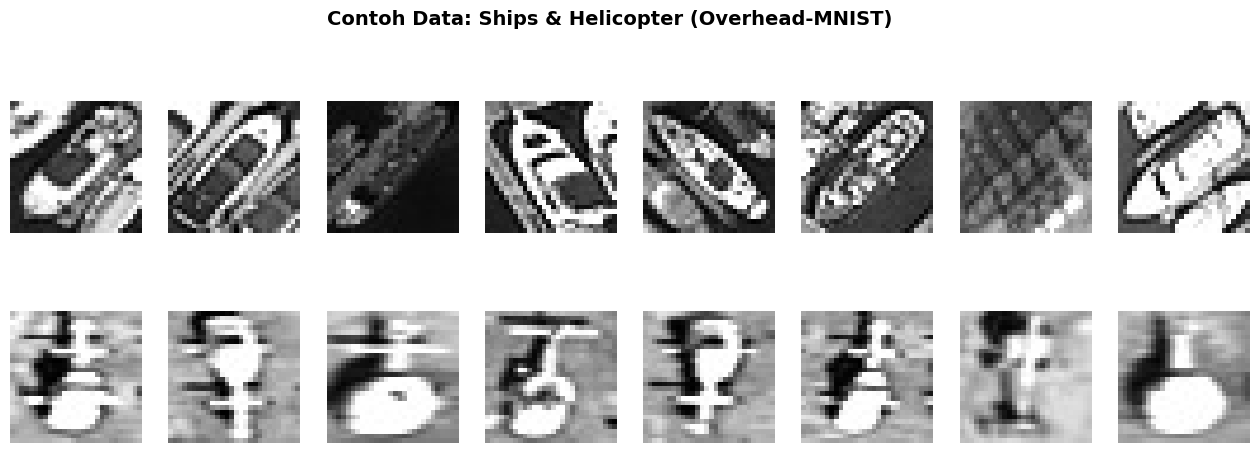

In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Contoh Data: Ships & Helicopter (Overhead-MNIST)', fontsize=14, fontweight='bold', y=1.02)

for cls_idx, cls_name in [(0, 'Ships'), (1, 'Helicopter')]:
    cls_samples = x[y == cls_idx]
    for j in range(8):
        ax = axes[cls_idx, j]
        ax.imshow(cls_samples[j], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
    axes[cls_idx, 0].set_ylabel(cls_name, fontsize=12, fontweight='bold', rotation=0, labelpad=60, va='center')

plt.show()

### Preprocessing

Pada tahap preprocessing, data gambar terlebih dahulu diubah dari bentuk matriks berukuran 28 x 28 menjadi vektor satu dimensi berukuran 784 menggunakan fungsi reshape(). Langkah ini dilakukan agar data dapat diproses sesuai dengan bentuk input yang digunakan pada model. Selanjutnya, dataset dibagi menjadi 80% data training, 10% data validation, dan 10% data testing menggunakan fungsi train_test_split(). Pembagian dilakukan dalam dua tahap. Pertama, sebanyak 10% data dipisahkan sebagai data testing. Kemudian, sisa data dibagi kembali menggunakan test_size=0.1111 sehingga diperoleh sekitar 80% data training dan 10% data validation. Parameter random_state=42 digunakan agar hasil pembagian data tetap sama setiap kali program dijalankan, sedangkan parameter stratify digunakan untuk menjaga agar jumlah data pada masing-masing kelas tetap seimbang di setiap subset.

In [ ]:
x_flat = x.reshape(len(x), -1)

x_temp, x_test, y_temp, y_test = train_test_split(
    x_flat, y, test_size=0.10, random_state=42, stratify=y)

x_train, x_val, y_train, y_val = train_test_split(
    x_temp, y_temp,
    test_size=0.1111,
    random_state=42, stratify=y_temp)

print(f"Training: {len(x_train)} sampel (80%)")
print(f"Validation: {len(x_val)} sampel (10%)")
print(f"Test: {len(x_test)} sampel (10%)")
print("\n=== Distribusi per kelas: ===")
for split_name, split_y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    s = np.sum(split_y==0); h = np.sum(split_y==1)
    print(f"{split_name}: Ships= {s}, Heli= {h}")

Training: 1389 sampel (80%)
Validation: 174 sampel (10%)
Test: 174 sampel (10%)

=== Distribusi per kelas: ===
Train: Ships= 800, Heli= 589
Val: Ships= 100, Heli= 74
Test: Ships= 100, Heli= 74


## 2B. Baseline Autoencoder

Baseline Autoencoder digunakan sebagai model dasar sebelum dilakukan pengembangan arsitektur yang lebih kompleks. Autoencoder terdiri dari dua bagian utama, yaitu Encoder dan Decoder. Encoder bertugas mengompresi gambar menjadi latent representation, sedangkan Decoder bertugas merekonstruksi kembali gambar dari representasi tersebut sehingga hasilnya menyerupai gambar asli.

Pada bagian Encoder, input terlebih dahulu diubah menjadi ukuran 28 x 28 x 1 menggunakan Reshape, kemudian diproses oleh Conv2D dengan 32 filter, ukuran kernel 3 x 3, fungsi aktivasi ReLU, dan padding='same' untuk mengekstraksi fitur-fitur penting pada gambar. Selanjutnya, MaxPooling2D digunakan untuk memperkecil ukuran feature map, kemudian Flatten mengubahnya menjadi vektor satu dimensi sebelum diproses oleh Dense untuk menghasilkan latent representation berukuran 128 dimensi (latent_dim = 128).

Pada bagian Decoder, latent representation diproses menggunakan Dense, kemudian diubah kembali menjadi feature map berukuran 14 x 14 x 32 menggunakan Reshape. Selanjutnya, UpSampling2D memperbesar ukuran feature map, kemudian Conv2D merekonstruksi gambar hingga berukuran 28 x 28. Layer output menggunakan fungsi aktivasi Sigmoid karena nilai piksel telah dinormalisasi ke rentang 0 hingga 1, kemudian hasilnya diubah kembali menjadi vektor berukuran 784 agar sesuai dengan bentuk input.

In [ ]:
def build_baseline_autoencoder(latent_dim=128):
    enc_input = keras.Input(shape=(784,), name='encoder_input')
    x = layers.Reshape((28, 28, 1))(enc_input)
    x = layers.Conv2D(32, (3,3), activation='relu',
                      padding='same', name='conv_relu')(x)
    x = layers.MaxPooling2D((2,2), name='max_pool')(x)
    x = layers.Flatten(name='flatten')(x)
    latent = layers.Dense(latent_dim, activation='relu',
                          name='latent')(x)
    encoder = Model(enc_input, latent, name='Encoder_Baseline')

    dec_input = keras.Input(shape=(latent_dim,), name='decoder_input')
    x = layers.Dense(6272, name='fc_decoder')(dec_input)
    x = layers.Reshape((14, 14, 32), name='reshape')(x)
    x = layers.UpSampling2D((2,2), name='upsample')(x)
    x = layers.Conv2D(32, (3,3), activation='relu',
                      padding='same', name='conv_relu_dec')(x)
    output = layers.Conv2D(1, (3,3), activation='sigmoid',
                           padding='same', name='conv_sigmoid')(x)
    output_flat = layers.Reshape((784,), name='output')(output)
    decoder = Model(dec_input, output_flat, name='Decoder_Baseline')

    ae_in = keras.Input(shape=(784,))
    autoencoder = Model(ae_in, decoder(encoder(ae_in)), name='Autoencoder_Baseline')

    return autoencoder, encoder, decoder

baseline_ae, baseline_enc, baseline_dec = build_baseline_autoencoder(latent_dim=128)

baseline_ae.summary()
print(f'\nTotal Parameter: {baseline_ae.count_params():,}')

Model: "Autoencoder_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_63 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_Baseline (Functional)   │ (None, 128)            │       803,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Baseline (Functional)   │ (None, 784)            │       818,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,621,889 (6.19 MB)

 Trainable params: 1,621,889 (6.19 MB)

 Non-trainable params: 0 (0.00 B)


Total Parameter: 1,621,889


Sebelum dilakukan pelatihan, model dikompilasi dengan menggunakan optimizer Adam, loss function Mean Squared Error (MSE), dan metrik evaluasi Mean Absolute Error (MAE). Optimizer Adam dipilih karena mampu melakukan penyesuaian learning rate secara adaptif sehingga proses optimasi menjadi lebih cepat dan stabil. Learning rate awal ditetapkan sebesar 0.001 (1e-3) sebagai nilai yang umum digunakan pada berbagai permasalahan computer vision. Fungsi loss MSE digunakan untuk mengukur rata-rata kuadrat selisih antara gambar asli dan hasil rekonstruksi, sedangkan MAE digunakan sebagai metrik tambahan untuk mengetahui rata-rata kesalahan absolut selama proses pelatihan.

In [ ]:
baseline_ae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

#### Train

In [ ]:
history_baseline = baseline_ae.fit(
    x_train, x_train,
    epochs=60,
    batch_size=64,
    validation_data=(x_val, x_val),
    verbose=1
)


Epoch 1/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - loss: 0.0973 - mae: 0.2703 - val_loss: 0.0879 - val_mae: 0.2540
Epoch 2/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0807 - mae: 0.2377 - val_loss: 0.0725 - val_mae: 0.2212
Epoch 3/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0669 - mae: 0.2076 - val_loss: 0.0638 - val_mae: 0.1997
Epoch 4/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0596 - mae: 0.1903 - val_loss: 0.0582 - val_mae: 0.1868
Epoch 5/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0548 - mae: 0.1794 - val_loss: 0.0544 - val_mae: 0.1783
Epoch 6/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0516 - mae: 0.1723 - val_loss: 0.0514 - val_mae: 0.1717
Epoch 7/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0490 - mae: 0.1665 - val_loss: 0.0493 - val_mae: 0.1673
Epoch 8/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0468 - mae: 0.1616 - val_loss: 0.0474 - val_mae: 0.1625
Epoch 9/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0452 - m

Model baseline ditraining menggunakan 60 epoch dengan batch size sebesar 64. Parameter epoch menunjukkan berapa kali seluruh data pelatihan diproses oleh model, sedangkan batch size menunjukkan jumlah data yang digunakan pada setiap proses pembaruan bobot. Selama pelatihan, data validasi digunakan untuk memantau kemampuan generalisasi model terhadap data yang tidak digunakan secara langsung dalam proses pembelajaran. Hasil training divisualisasikan dalam bentuk grafik training loss dan validation loss. Apabila kedua kurva mengalami penurunan secara bersamaan dan tidak memiliki perbedaan yang terlalu besar, maka dapat diinterpretasikan bahwa model mampu belajar dengan baik dan belum mengalami overfitting.

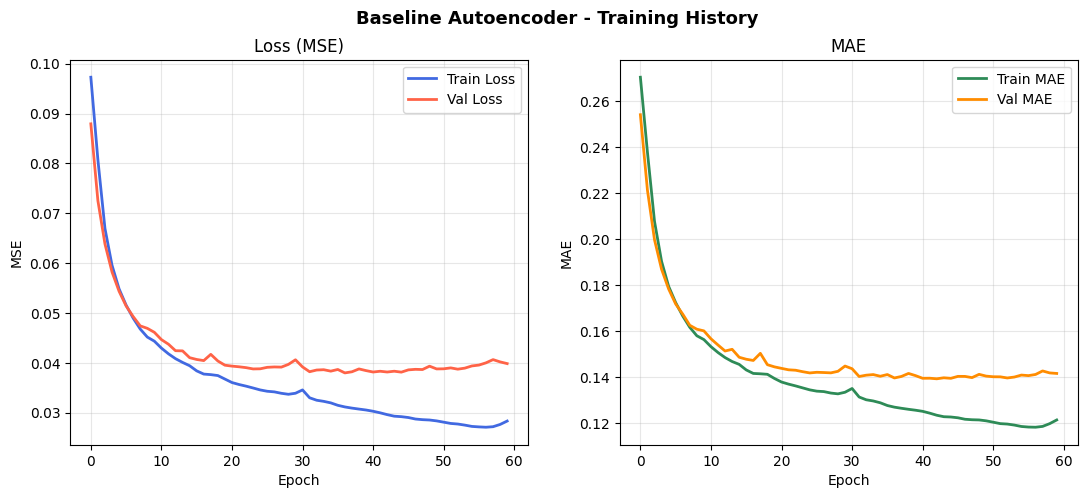

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Baseline Autoencoder - Training History',
             fontsize=13, fontweight='bold')

axes[0].plot(history_baseline.history['loss'], color='royalblue', lw=2, label='Train Loss')
axes[0].plot(history_baseline.history['val_loss'], color='tomato', lw=2, label='Val Loss')
axes[0].set_title('Loss (MSE)'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_baseline.history['mae'], color='seagreen', lw=2, label='Train MAE')
axes[1].plot(history_baseline.history['val_mae'], color='darkorange', lw=2, label='Val MAE')
axes[1].set_title('MAE'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.show()

Grafik Training History menunjukkan bahwa nilai training loss, validation loss, training MAE, dan validation MAE mengalami penurunan yang signifikan pada awal proses training, kemudian mulai stabil seiring bertambahnya epoch. Di akhir training, training loss masih terus menurun, sedangkan validation loss cenderung stabil dengan sedikit kenaikan, yang menunjukkan adanya gejala overfitting ringan. Namun, karena selisih antara nilai training dan validation tidak terlalu besar, model masih memiliki kemampuan yang cukup baik dalam merekonstruksi gambar pada data yang belum pernah dilihat.

In [ ]:
def compute_ssim_batch(original, reconstructed):
    scores = []
    for orig, recon in zip(original, reconstructed):
        score = ssim(orig.reshape(28, 28), recon.reshape(28, 28), data_range=1.0)
        scores.append(score)
    return np.array(scores)

x_test_recon_baseline = baseline_ae.predict(x_test, verbose=0)
ssim_baseline = compute_ssim_batch(x_test, x_test_recon_baseline)

print("=== Evaluasi Baseline Autoencoder (SSIM) ===")
print(f"SSIM Mean: {ssim_baseline.mean():.4f}")
print(f"SSIM Std: {ssim_baseline.std():.4f}")
print(f"SSIM Min: {ssim_baseline.min():.4f}")
print(f"SSIM Max: {ssim_baseline.max():.4f}")

print("\n=== SSIM per kelas: ===")
for cls_idx, cls_name in [(0, 'Ships'), (1, 'Helicopter')]:
    mask = y_test == cls_idx
    print(f"{cls_name:11s}: {ssim_baseline[mask].mean():.4f} +- {ssim_baseline[mask].std():.4f}")

=== Evaluasi Baseline Autoencoder (SSIM) ===
SSIM Mean: 0.5511
SSIM Std: 0.1542
SSIM Min: 0.1342
SSIM Max: 0.8983

=== SSIM per kelas: ===
Ships      : 0.4996 +- 0.1190
Helicopter : 0.6206 +- 0.1684


Evaluasi menggunakan Structural Similarity Index Measure (SSIM) menunjukkan bahwa Baseline Autoencoder memperoleh SSIM Mean sebesar 0.5511 dengan nilai minimum 0.1342 dan maksimum 0.8983. Hasil ini menunjukkan bahwa model sudah mampu merekonstruksi struktur utama gambar dengan cukup baik, meskipun kualitas rekonstruksi masih bervariasi pada beberapa sampel. Berdasarkan hasil per kelas, Helicopter memperoleh rata-rata SSIM yang lebih tinggi (0.6206 +- 0.1684) dibandingkan Ships (0.4996 +- 0.1190), sehingga model mampu merekonstruksi gambar Helicopter dengan tingkat kemiripan yang lebih baik dibandingkan gambar Ships.

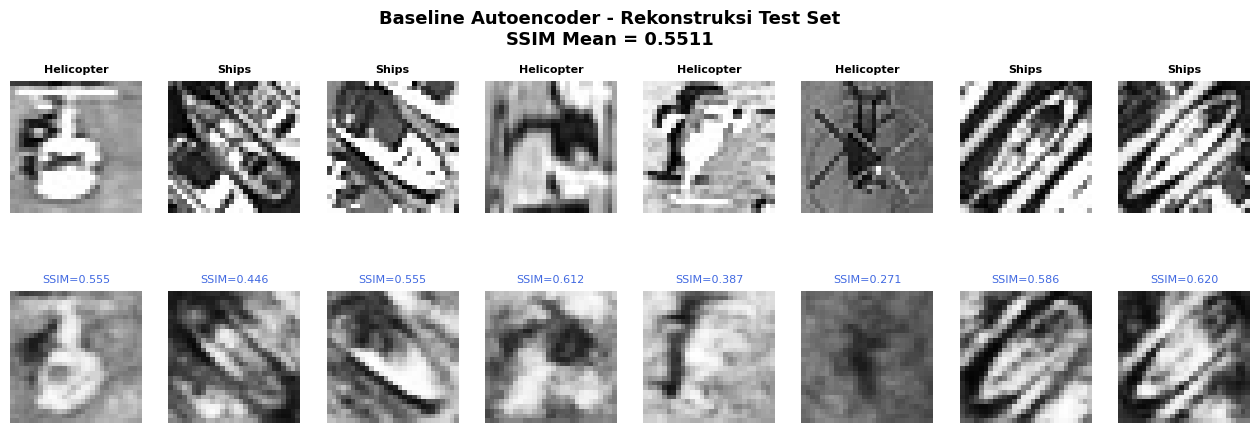

In [ ]:
n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(16, 5))
fig.suptitle(f'Baseline Autoencoder - Rekonstruksi Test Set\nSSIM Mean = {ssim_baseline.mean():.4f}',
             fontsize=13, fontweight='bold')

for j in range(n_show):
    orig  = x_test[j].reshape(28, 28)
    recon = x_test_recon_baseline[j].reshape(28, 28)

    axes[0, j].imshow(orig,  cmap='gray', vmin=0, vmax=1)
    axes[1, j].imshow(recon, cmap='gray', vmin=0, vmax=1)

    axes[0, j].set_title(class_names[y_test[j]], fontsize=8, fontweight='bold')
    axes[1, j].set_title(f'SSIM={ssim_baseline[j]:.3f}', fontsize=8, color='royalblue')

for i, lbl in enumerate(['Original', 'Rekonstruksi']):
    axes[i, 0].set_ylabel(lbl, fontsize=9, fontweight='bold',
                          rotation=0, labelpad=70, va='center')
for ax in axes.flatten(): ax.axis('off')

plt.show()

Gambar di atas menunjukkan perbandingan antara citra asli (baris atas) dan citra hasil rekonstruksi oleh Baseline Autoencoder (baris bawah) pada data testing. Secara umum, model telah mampu mempertahankan bentuk dan pola utama dari objek, namun beberapa detail masih terlihat kurang jelas sehingga hasil rekonstruksi tampak lebih buram dibandingkan citra asli. Nilai SSIM Mean sebesar 0.5511 menunjukkan bahwa tingkat kemiripan hasil rekonstruksi masih berada pada kategori sedang, yang sejalan dengan visualisasi gambar di mana sebagian citra memiliki hasil rekonstruksi yang cukup baik, sedangkan beberapa citra lainnya masih kehilangan detail penting.

## 2C. Improved Autoencoder & Hyperparameter Tuning

Pada tahap ini dibangun Improved Autoencoder dengan arsitektur yang lebih dalam dibandingkan Baseline Autoencoder agar mampu mengekstraksi fitur yang lebih kompleks. Pada bagian Encoder, input terlebih dahulu diubah menjadi ukuran 28 × 28 × 1 menggunakan Reshape, kemudian diproses menggunakan empat layer Conv2D dengan jumlah filter 64 dan 128, ukuran kernel 3 × 3, fungsi aktivasi ReLU, serta dua MaxPooling2D untuk memperkecil ukuran feature map. Hasilnya kemudian diubah menjadi vektor satu dimensi menggunakan Flatten sebelum diproses oleh Dense untuk menghasilkan latent representation berukuran 128 dimensi.

Pada bagian Decoder, latent representation diproses menggunakan Dense dan Reshape menjadi feature map berukuran 7 × 7 × 128. Selanjutnya, kombinasi layer Conv2D dan UpSampling2D digunakan untuk merekonstruksi gambar hingga kembali berukuran 28 × 28. Layer output menggunakan fungsi aktivasi Sigmoid karena nilai piksel telah dinormalisasi ke rentang 0–1, kemudian hasil rekonstruksi diubah kembali menjadi vektor berukuran 784 agar sesuai dengan bentuk input.

In [ ]:
def build_improved_autoencoder(latent_dim=128):
    enc_input = keras.Input(shape=(784,), name='encoder_input')
    x = layers.Reshape((28, 28, 1))(enc_input)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same', name='enc_conv1')(x)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same', name='enc_conv2')(x)
    x = layers.MaxPooling2D((2,2), name='enc_pool1')(x)
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same', name='enc_conv3')(x)
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same', name='enc_conv4')(x)
    x = layers.MaxPooling2D((2,2), name='enc_pool2')(x)
    x = layers.Flatten(name='enc_flatten')(x)
    latent = layers.Dense(latent_dim, activation='relu', name='latent')(x)
    encoder = Model(enc_input, latent, name='Encoder_Improved')

    dec_input = keras.Input(shape=(latent_dim,), name='decoder_input')
    x = layers.Dense(7*7*128, activation='relu', name='dec_dense')(dec_input)
    x = layers.Reshape((7, 7, 128), name='dec_reshape')(x)
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same', name='dec_conv1')(x)
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same', name='dec_conv2')(x)
    x = layers.UpSampling2D((2,2), name='dec_up1')(x)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same', name='dec_conv3')(x)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same', name='dec_conv4')(x)
    x = layers.UpSampling2D((2,2), name='dec_up2')(x)
    output = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same', name='dec_output')(x)
    out_flat = layers.Reshape((784,), name='output')(output)
    decoder = Model(dec_input, out_flat, name='Decoder_Improved')

    ae_in = keras.Input(shape=(784,))
    autoencoder = Model(ae_in, decoder(encoder(ae_in)), name='Autoencoder_Improved')
    return autoencoder, encoder, decoder

improved_ae, improved_enc, improved_dec = build_improved_autoencoder(latent_dim=128)
improved_ae.summary()
print(f'\nTotal Parameter: {improved_ae.count_params():,}')


Model: "Autoencoder_Improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_76 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_Improved (Functional)   │ (None, 128)            │     1,061,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Improved (Functional)   │ (None, 784)            │     1,215,553 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,505 (8.69 MB)

 Trainable params: 2,277,505 (8.69 MB)

 Non-trainable params: 0 (0.00 B)


Total Parameter: 2,277,505


In [ ]:
improved_ae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='mse',
    metrics=['mae']
)

callbacks_improved = [
    EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7, verbose=1)
]

history_improved = improved_ae.fit(
    x_train, x_train,
    epochs=200,
    batch_size=32,
    validation_data=(x_val, x_val),
    callbacks=callbacks_improved,
    verbose=1
)

Epoch 1/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0967 - mae: 0.2690 - val_loss: 0.0849 - val_mae: 0.2464 - learning_rate: 5.0000e-04
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0747 - mae: 0.2238 - val_loss: 0.0656 - val_mae: 0.2009 - learning_rate: 5.0000e-04
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0589 - mae: 0.1883 - val_loss: 0.0554 - val_mae: 0.1801 - learning_rate: 5.0000e-04
Epoch 4/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0531 - mae: 0.1749 - val_loss: 0.0534 - val_mae: 0.1746 - learning_rate: 5.0000e-04
Epoch 5/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0496 - mae: 0.1669 - val_loss: 0.0493 - val_mae: 0.1665 - learning_rate: 5.0000e-04
Epoch 6/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0466 - mae: 0.1602 - val_loss: 0.0462 - val_mae: 0.1588 - learning_rate: 5.0000e-04
Epoch 7/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0441 - mae: 0.1550 - val_loss: 0.0437 - val_mae: 0.1532 - lea

Selama proses training Improved Autoencoder digunakan optimizer Adam dengan learning rate sebesar 0.0005, loss function berupa Mean Squared Error (MSE), serta metrik Mean Absolute Error (MAE) untuk mengevaluasi performa model. Selain itu, digunakan dua callback, yaitu EarlyStopping dan ReduceLROnPlateau. EarlyStopping menggunakan parameter patience = 25, yang berarti proses training akan dihentikan apabila validation loss tidak mengalami perbaikan selama 25 epoch berturut-turut, kemudian model akan mengembalikan bobot terbaik (restore_best_weights=True). Sementara itu, ReduceLROnPlateau akan menurunkan learning rate sebesar 50% (factor = 0.5) apabila validation loss tidak mengalami perbaikan selama 8 epoch, dengan batas minimum 1e-7. Penggunaan kedua callback ini bertujuan untuk mengurangi risiko overfitting serta membantu model mencapai performa yang lebih optimal.

### Hyperparameter Tuning

Pada tahap ini dilakukan hyperparameter tuning menggunakan Grid Search untuk mencari kombinasi learning rate dan batch size yang memberikan hasil rekonstruksi terbaik. Nilai learning rate yang diuji adalah 0.001, 0.0005, dan 0.0001, sedangkan batch size yang digunakan adalah 32 dan 64, sehingga diperoleh 6 kombinasi hyperparameter. Setelah training selesai, model digunakan untuk merekonstruksi data testing, kemudian dihitung nilai rata-rata SSIM sebagai dasar pemilihan model terbaik. Kombinasi dengan nilai SSIM tertinggi dipilih, kemudian digunakan kembali untuk melatih Improved Autoencoder dengan maksimum 200 epoch menggunakan EarlyStopping (patience = 25) dan ReduceLROnPlateau untuk memperoleh model akhir dengan performa yang lebih optimal.

In [ ]:
param_grid = {
    'learning_rate': [1e-3, 5e-4, 1e-4],
    'batch_size': [32, 64]
}

tuning_results = []

for lr in param_grid['learning_rate']:
    for bs in param_grid['batch_size']:
        ae_tmp, _, _ = build_improved_autoencoder(latent_dim=128)
        ae_tmp.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss='mse', metrics=['mae'])
        cb = [EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)]
        ae_tmp.fit(x_train, x_train, epochs=60, batch_size=bs,
                   validation_data=(x_val, x_val), callbacks=cb, verbose=0)
        recon_tmp = ae_tmp.predict(x_test, verbose=0)
        ssim_score = compute_ssim_batch(x_test, recon_tmp).mean()
        tuning_results.append({'lr': lr, 'batch_size': bs, 'ssim': ssim_score})
        print(f"lr={lr:.0e}, batch={bs} -> SSIM={ssim_score:.4f}")

best = max(tuning_results, key=lambda d: d['ssim'])
print(f"\nBest: lr={best['lr']:.0e}, batch_size={best['batch_size']}, SSIM={best['ssim']:.4f}")

improved_ae, improved_enc, improved_dec = build_improved_autoencoder(latent_dim=128)
improved_ae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best['lr']),
    loss='mse',
    metrics=['mae']
)
callbacks_best = [
    EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7, verbose=1)
]
history_improved = improved_ae.fit(
    x_train, x_train,
    epochs=200,
    batch_size=best['batch_size'],
    validation_data=(x_val, x_val),
    callbacks=callbacks_best,
    verbose=1
)


lr=1e-03, batch=32 -> SSIM=0.5066
lr=1e-03, batch=64 -> SSIM=0.5353
lr=5e-04, batch=32 -> SSIM=0.5763
lr=5e-04, batch=64 -> SSIM=0.5820
lr=1e-04, batch=32 -> SSIM=0.6187
lr=1e-04, batch=64 -> SSIM=0.5709

Best: lr=1e-04, batch_size=32, SSIM=0.6187
Epoch 1/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.1008 - mae: 0.2765 - val_loss: 0.0942 - val_mae: 0.2654 - learning_rate: 1.0000e-04
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0937 - mae: 0.2644 - val_loss: 0.0858 - val_mae: 0.2484 - learning_rate: 1.0000e-04
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0788 - mae: 0.2343 - val_loss: 0.0729 - val_mae: 0.2173 - learning_rate: 1.0000e-04
Epoch 4/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0653 - mae: 0.2037 - val_loss: 0.0620 - val_mae: 0.1948 - learning_rate: 1.0000e-04
Epoch 5/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0586 - mae: 0.1881 - val_loss: 0.0578 - val_mae: 0.1856 - learning_rate: 1.0000e-04
Epoch 6/200
44/44 ━━━

In [ ]:
x_test_recon_improved = improved_ae.predict(x_test, verbose=0)
ssim_improved = compute_ssim_batch(x_test, x_test_recon_improved)

print("=== Evaluasi Improved Model (Best Hyperparameter) ===")
print(f"SSIM Mean: {ssim_improved.mean():.4f}")
print(f"SSIM Std: {ssim_improved.std():.4f}")
print(f"SSIM Min: {ssim_improved.min():.4f}")
print(f"SSIM Max: {ssim_improved.max():.4f}")

print("\n=== SSIM per kelas: ===")
for cls_idx, cls_name in [(0, 'Ships'), (1, 'Helicopter')]:
    mask = y_test == cls_idx
    print(f"{cls_name:11s}: {ssim_improved[mask].mean():.4f} +- {ssim_improved[mask].std():.4f}")


=== Evaluasi Improved Model (Best Hyperparameter) ===
SSIM Mean: 0.6491
SSIM Std: 0.1218
SSIM Min: 0.3437
SSIM Max: 0.9036

=== SSIM per kelas: ===
Ships      : 0.5959 +- 0.0916
Helicopter : 0.7211 +- 0.1207


Hasil evaluasi menunjukkan bahwa Improved Autoencoder memperoleh SSIM Mean sebesar 0.6491, dengan nilai minimum 0.3437 dan maksimum 0.9036. Nilai ini lebih tinggi dibandingkan Baseline Autoencoder, sehingga menunjukkan bahwa model mampu merekonstruksi gambar dengan tingkat kemiripan yang lebih baik. Berdasarkan hasil per kelas, Helicopter memperoleh rata-rata SSIM sebesar 0.7211 +- 0.1207, sedangkan Ships memperoleh 0.5959 +- 0.0916. Hasil tersebut menunjukkan bahwa Improved Autoencoder mampu meningkatkan kualitas rekonstruksi pada kedua kelas, terutama pada kelas Helicopter, sehingga gambar hasil rekonstruksi menjadi lebih mendekati citra asli.

## Evaluasi

In [ ]:
improvement = (ssim_improved.mean() - ssim_baseline.mean()) / ssim_baseline.mean() * 100

print(f"Baseline SSIM: {ssim_baseline.mean():.4f} (latent dim=128)")
print(f"Improved SSIM: {ssim_improved.mean():.4f} (latent dim=128)")
print(f"Perubahan SSIM: {improvement:+.2f}%")

Baseline SSIM: 0.5511 (latent dim=128)
Improved SSIM: 0.6491 (latent dim=128)
Perubahan SSIM: +17.79%


Berdasarkan hasil evaluasi, Baseline Autoencoder memperoleh SSIM sebesar 0.5511, sedangkan Improved Autoencoder memperoleh SSIM sebesar 0.6491. Hal ini menunjukkan bahwa pengembangan arsitektur pada Improved Autoencoder berhasil meningkatkan kualitas rekonstruksi gambar. Secara keseluruhan, nilai SSIM meningkat sebesar 17.79%, yang menunjukkan bahwa hasil rekonstruksi model improved lebih mendekati citra asli dibandingkan model baseline.

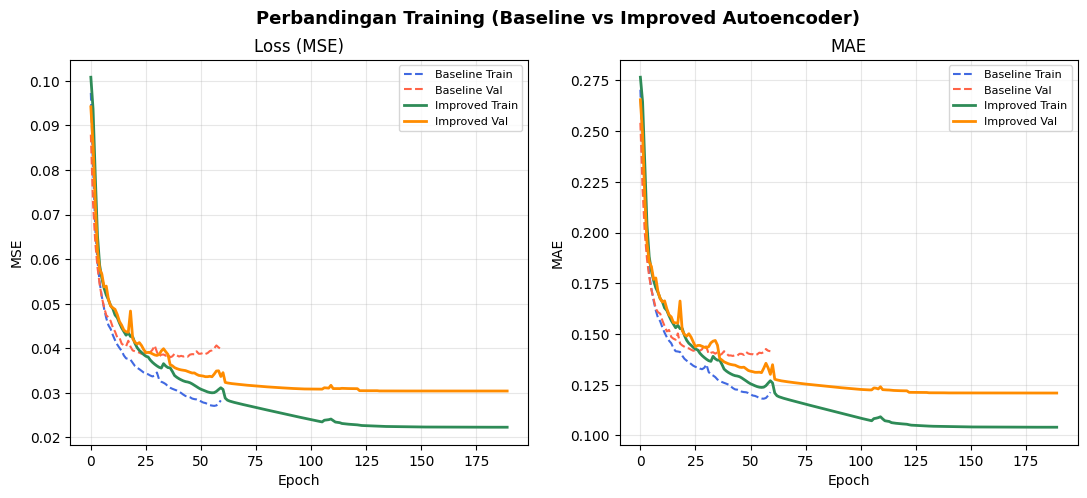

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Perbandingan Training (Baseline vs Improved Autoencoder)',
             fontsize=13, fontweight='bold')

axes[0].plot(history_baseline.history['loss'], '--', color='royalblue', lw=1.5, label='Baseline Train')
axes[0].plot(history_baseline.history['val_loss'], '--', color='tomato', lw=1.5, label='Baseline Val')
axes[0].plot(history_improved.history['loss'], '-', color='seagreen', lw=2, label='Improved Train')
axes[0].plot(history_improved.history['val_loss'], '-', color='darkorange',lw=2, label='Improved Val')
axes[0].set_title('Loss (MSE)'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(history_baseline.history['mae'], '--', color='royalblue', lw=1.5, label='Baseline Train')
axes[1].plot(history_baseline.history['val_mae'], '--', color='tomato', lw=1.5, label='Baseline Val')
axes[1].plot(history_improved.history['mae'], '-',  color='seagreen',  lw=2, label='Improved Train')
axes[1].plot(history_improved.history['val_mae'], '-',  color='darkorange',lw=2, label='Improved Val')
axes[1].set_title('MAE'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.show()

Grafik menunjukkan bahwa Baseline Autoencoder dan Improved Autoencoder sama-sama mengalami penurunan nilai Loss (MSE) dan MAE selama proses training. Namun, Improved Autoencoder menghasilkan nilai training loss dan training MAE yang lebih rendah dibandingkan model baseline, menunjukkan bahwa model mampu mempelajari representasi data dengan lebih baik. Meskipun validation loss dan validation MAE masih sedikit lebih tinggi daripada data training, nilainya cenderung stabil hingga akhir proses training, sehingga menunjukkan bahwa model memiliki kemampuan generalisasi yang lebih baik.

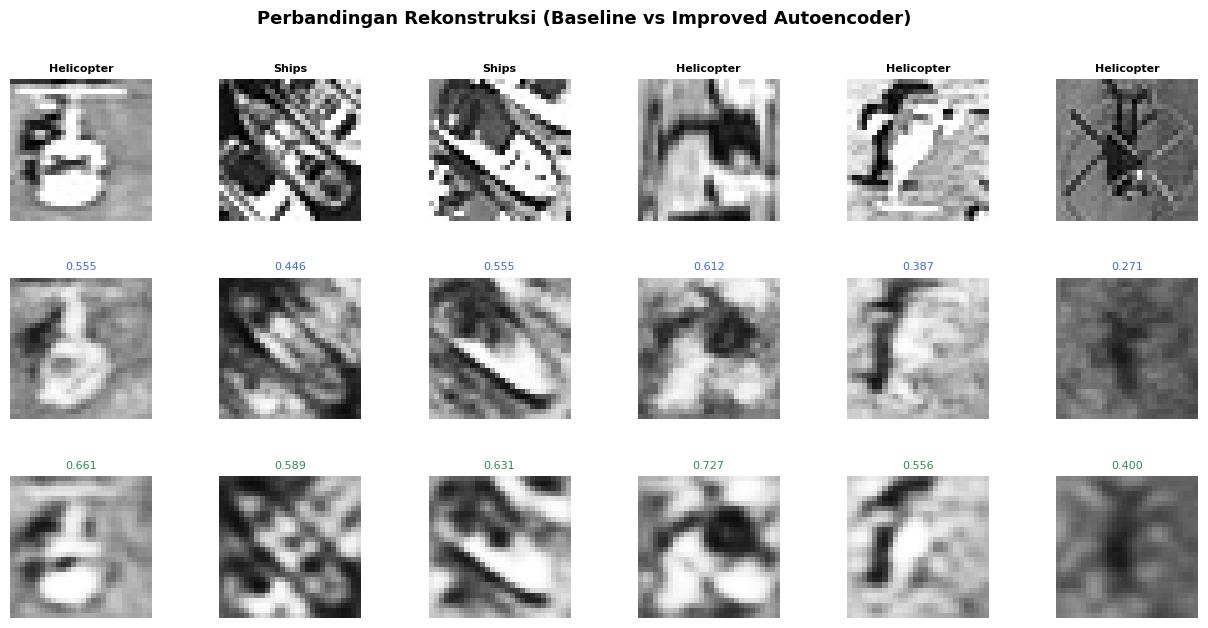

In [ ]:
n_show = 6
fig = plt.figure(figsize=(16, 7))
fig.suptitle('Perbandingan Rekonstruksi (Baseline vs Improved Autoencoder)',
             fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(3, n_show, hspace=0.4, wspace=0.08)

for j in range(n_show):
    orig = x_test[j].reshape(28, 28)
    br = x_test_recon_baseline[j].reshape(28, 28)
    ir = x_test_recon_improved[j].reshape(28, 28)

    a0 = fig.add_subplot(gs[0, j])
    a1 = fig.add_subplot(gs[1, j])
    a2 = fig.add_subplot(gs[2, j])

    a0.imshow(orig, cmap='gray', vmin=0, vmax=1)
    a1.imshow(br, cmap='gray', vmin=0, vmax=1)
    a2.imshow(ir, cmap='gray', vmin=0, vmax=1)

    a0.set_title(class_names[y_test[j]], fontsize=8, fontweight='bold')
    a1.set_title(f'{ssim_baseline[j]:.3f}', fontsize=8, color='royalblue')
    a2.set_title(f'{ssim_improved[j]:.3f}', fontsize=8, color='seagreen')

    if j == 0:
        row_lbls = ['Original',
                    f'Baseline\n(SSIM={ssim_baseline.mean():.4f})',
                    f'Improved\n(SSIM={ssim_improved.mean():.4f})']
        for ax, lbl in zip([a0, a1, a2], row_lbls):
            ax.set_ylabel(lbl, fontsize=7.5, fontweight='bold',
                          rotation=0, labelpad=75, va='center')
    for ax in [a0, a1, a2]: ax.axis('off')

plt.show()

Gambar di atas memperlihatkan perbandingan antara citra asli (baris pertama), hasil rekonstruksi Baseline Autoencoder (baris kedua), dan hasil rekonstruksi Improved Autoencoder (baris ketiga). Secara umum, hasil rekonstruksi Improved Autoencoder tampak lebih mendekati citra asli dengan bentuk objek yang lebih jelas dibandingkan model baseline. Hal ini juga terlihat dari nilai SSIM yang pada sebagian besar sampel mengalami peningkatan, sehingga menunjukkan bahwa pengembangan arsitektur berhasil meningkatkan kualitas rekonstruksi gambar.

## 3D. Video Penjelasan

Link Video: https://drive.google.com/file/d/1L6lRo0dudwCOyHJ9escP-82HSAUo7uz0/view?usp=sharing